# ICU Length-of-Stay Demo

This notebook is the lightweight GitHub demonstration for the STATS 170B capstone project. The full project used restricted MIMIC-IV data, so this notebook uses a small hand-created synthetic sample with the same kind of first-24-hour ICU features. It trains quick classification models and shows the kinds of predictions and errors the final project analyzed.

## 1. Load the sample data

The target is `longer_than_2d`: `0` means a short ICU stay of 2 days or less, and `1` means a longer ICU stay.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

DATA_PATH = Path('data/sample/fake_icu_los_sample.csv')
df = pd.read_csv(DATA_PATH)
print(f'Loaded {len(df)} synthetic ICU stays from {DATA_PATH}')
df.head()

Loaded 72 synthetic ICU stays from data/sample/fake_icu_los_sample.csv


,stay_id,age,first_careunit,admission_type,heart_rate_mean_24h,map_mean_24h,lactate_max_24h,radiology_note_count_24h,procedure_event_count_24h,medication_count_24h,abnormal_radiology_flag_24h,los_days,longer_than_2d
0,100000,49,MICU,EMERGENCY,83.8,77.5,1.11,0,1,5,0,1.88,0
1,100001,45,TSICU,EMERGENCY,91.5,87.9,0.74,1,1,5,0,5.72,1
2,100002,46,CCU,ELECTIVE,65.3,72.0,2.71,2,0,4,1,1.28,0
3,100003,53,TSICU,EMERGENCY,88.5,29.8,0.60,2,2,6,0,2.69,1
4,100004,67,CCU,EMERGENCY,80.3,78.7,3.75,5,1,2,1,5.95,1


## 2. Train fast demo models

The real project evaluated multiple model families. This compact demo compares logistic regression with a random forest on the sample data. The point is to demonstrate the pipeline mechanics, not to reproduce the full MIMIC-IV results.

In [2]:
target = 'longer_than_2d'
feature_cols = [
    'age', 'first_careunit', 'admission_type', 'heart_rate_mean_24h',
    'map_mean_24h', 'lactate_max_24h', 'radiology_note_count_24h',
    'procedure_event_count_24h', 'medication_count_24h', 'abnormal_radiology_flag_24h',
]

X = df[feature_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=170, stratify=y
)

numeric_features = X.select_dtypes(include='number').columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

preprocess = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
])

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=170),
    'Random Forest': RandomForestClassifier(n_estimators=80, max_depth=4, random_state=170),
}

results = []
fitted = {}
for name, estimator in models.items():
    pipe = Pipeline([('preprocess', preprocess), ('model', estimator)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    fitted[name] = pipe
    results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'short_stay_f1': f1_score(y_test, pred, pos_label=0),
        'roc_auc': roc_auc_score(y_test, proba),
    })

results_df = pd.DataFrame(results).round(3)
results_df

,model,accuracy,short_stay_f1,roc_auc
0,Logistic Regression,0.682,0.696,0.742
1,Random Forest,0.727,0.667,0.750


## 3. Visualize model behavior

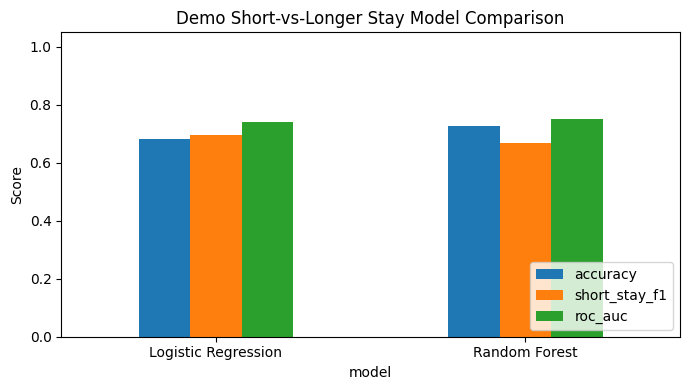

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_df = results_df.set_index('model')[['accuracy', 'short_stay_f1', 'roc_auc']]
plot_df.plot(kind='bar', ax=ax)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Demo Short-vs-Longer Stay Model Comparison')
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

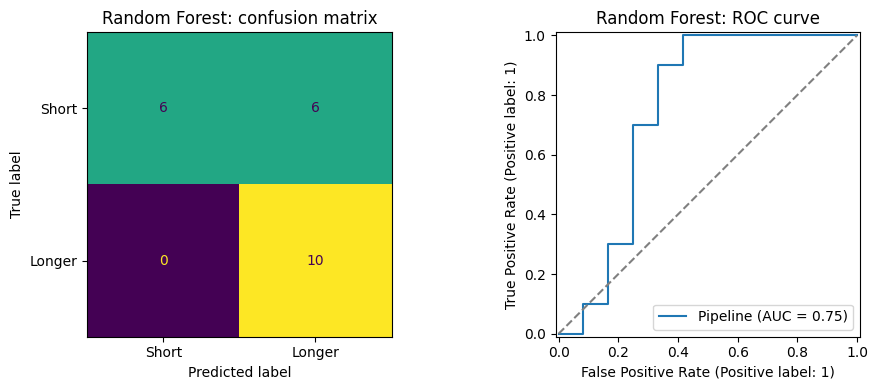

In [4]:
best_name = results_df.sort_values('roc_auc', ascending=False).iloc[0]['model']
best_model = fitted[best_name]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, display_labels=['Short', 'Longer'], ax=axes[0], colorbar=False)
axes[0].set_title(f'{best_name}: confusion matrix')
RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_title(f'{best_name}: ROC curve')
plt.tight_layout()
plt.show()

## 4. Example predictions

These rows show the type of output the full project can produce: an estimated probability that an ICU stay will last longer than 2 days.

In [5]:
example_rows = X_test.copy()
example_rows['actual_longer_than_2d'] = y_test.values
example_rows['predicted_probability_longer_than_2d'] = best_model.predict_proba(X_test)[:, 1]
example_rows['predicted_label'] = best_model.predict(X_test)
example_rows.sort_values('predicted_probability_longer_than_2d', ascending=False).head(8).round(3)

,age,first_careunit,admission_type,heart_rate_mean_24h,map_mean_24h,lactate_max_24h,radiology_note_count_24h,procedure_event_count_24h,medication_count_24h,abnormal_radiology_flag_24h,actual_longer_than_2d,predicted_probability_longer_than_2d,predicted_label
68,79,CCU,EMERGENCY,93.9,63.0,1.88,1,0,5,1,0,0.874,1
66,88,TSICU,EMERGENCY,90.0,66.9,2.70,1,1,3,0,1,0.862,1
18,51,SICU,URGENT,100.2,68.9,1.97,2,2,4,0,0,0.838,1
54,78,TSICU,URGENT,112.2,67.8,0.78,3,0,3,1,1,0.763,1
65,45,CCU,EMERGENCY,92.0,76.9,2.39,0,2,2,0,1,0.730,1
9,80,CVICU,ELECTIVE,107.1,60.5,0.60,3,1,5,0,0,0.720,1
3,53,TSICU,EMERGENCY,88.5,29.8,0.60,2,2,6,0,1,0.675,1
16,84,CCU,EMERGENCY,80.2,76.4,3.86,1,1,1,1,1,0.671,1


## 5. What this demo represents

In the full project, these same pipeline ideas were applied to MIMIC-IV ICU stays using first-24-hour clinical features, radiology indicators, intervention counts, and model evaluation plots. The full raw data is restricted and much too large for GitHub, so this notebook provides a reproducible miniature demonstration suitable for repository review.